In [2]:
# Notebook 3.0: Model Optimization & Final Evaluation
# Objective:  train, tune, and evaluate a comprehensive suite of machine learning algorithms to predict user churn.
# Methodology:
# Train-Validation-Test Splitting: Partition data into three strict subsets (70% Train / 15% Validation / 15% Test) to ensure complete isolation of the final testing pool.
# Algorithmic Benchmarking: Train 7 distinct architectures on the training set and evaluate performance on the validation set to pick our top contenders.
# Hyperparameter Tuning: Execute a GridSearchCV hyperparameter sweep on our top models to find the optimal mathematical dials.
# Final Locked Exam: Deploy our fully optimized champion model onto the untouched Test Set for final, unbiased evaluation.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install xgboost

# Splitting & Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Model Suite
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier 

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix

# Load final feature matrix from Notebook 2.0
user_df = pd.read_csv('endomondo_user_features.csv')
print(f"Dataset successfully loaded. Shape: {user_df.shape} users.")

Dataset successfully loaded. Shape: (1059, 9) users.


In [4]:
# Separate features (X) and target label (y)
X = user_df.drop(columns=['userId', 'churned'])
y = user_df['churned']

# Step 1: Extract the final Test Set (15% of total data)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Step 2: Split the remaining 85% into Train (70% total) and Validation (15% total)
# 0.1764 represents roughly 15% out of the remaining 85%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1764, random_state=42, stratify=y_temp
)

# Step 3: Feature Scaling (Fit ONLY on training data to prevent leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("--- DATA PARTITION SUMMARY ---")
print(f"Training Set   (70%): {X_train_scaled.shape[0]} users (Used to train basic models)")
print(f"Validation Set (15%): {X_val_scaled.shape[0]} users (Used to compare and tune models)")
print(f"Testing Set    (15%): {X_test_scaled.shape[0]} users (Locked away for the final exam)")

# A master dictionary to collect our tuned models' validation performances
final_comparison_metrics = {}
print("Data subsets locked and loaded!")

--- DATA PARTITION SUMMARY ---
Training Set   (70%): 741 users (Used to train basic models)
Validation Set (15%): 159 users (Used to compare and tune models)
Testing Set    (15%): 159 users (Locked away for the final exam)
Data subsets locked and loaded!


In [5]:
# Model 1: DummyClassifier
from sklearn.dummy import DummyClassifier

print("Evaluating Dummy Baseline...")
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train_scaled, y_train)
y_pred = dummy.predict(X_val_scaled)

final_comparison_metrics["Dummy Baseline"] = {
    "Accuracy": accuracy_score(y_val, y_pred), "Precision": precision_score(y_val, y_pred, zero_division=0),
    "Recall": recall_score(y_val, y_pred, zero_division=0), "F1-Score": f1_score(y_val, y_pred, zero_division=0)
}

Evaluating Dummy Baseline...


In [6]:
# Model 2: LogisticRegression
from sklearn.linear_model import LogisticRegression

print("Tuning Logistic Regression...")
lr_grid = {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}
grid_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=5000), lr_grid, scoring='f1', cv=3)
grid_lr.fit(X_train_scaled, y_train)

best_lr = grid_lr.best_estimator_
y_pred = best_lr.predict(X_val_scaled)

final_comparison_metrics["Logistic Regression (Tuned)"] = {
    "Accuracy": accuracy_score(y_val, y_pred), "Precision": precision_score(y_val, y_pred, zero_division=0),
    "Recall": recall_score(y_val, y_pred, zero_division=0), "F1-Score": f1_score(y_val, y_pred, zero_division=0)
}
print(f"Best Params: {grid_lr.best_params_}")

Tuning Logistic Regression...
Best Params: {'C': 1, 'solver': 'liblinear'}


In [7]:
# Model 3: K nearest neighbors
from sklearn.neighbors import KNeighborsClassifier

print("Tuning K-Nearest Neighbors...")
knn_grid = {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance']}
grid_knn = GridSearchCV(KNeighborsClassifier(), knn_grid, scoring='f1', cv=3)
grid_knn.fit(X_train_scaled, y_train)

best_knn = grid_knn.best_estimator_
y_pred = best_knn.predict(X_val_scaled)

final_comparison_metrics["K-Nearest Neighbors (Tuned)"] = {
    "Accuracy": accuracy_score(y_val, y_pred), "Precision": precision_score(y_val, y_pred, zero_division=0),
    "Recall": recall_score(y_val, y_pred, zero_division=0), "F1-Score": f1_score(y_val, y_pred, zero_division=0)
}
print(f"Best Params: {grid_knn.best_params_}")

Tuning K-Nearest Neighbors...


/Users/lmgc/opt/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
/Users/lmgc/opt/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be 

Best Params: {'n_neighbors': 7, 'weights': 'uniform'}


/Users/lmgc/opt/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


In [8]:
# Model 4: SVM
from sklearn.svm import SVC

print("Tuning Support Vector Machine...")
svm_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
grid_svm = GridSearchCV(SVC(random_state=42), svm_grid, scoring='f1', cv=3)
grid_svm.fit(X_train_scaled, y_train)

best_svm = grid_svm.best_estimator_
y_pred = best_svm.predict(X_val_scaled)

final_comparison_metrics["Support Vector Machine (Tuned)"] = {
    "Accuracy": accuracy_score(y_val, y_pred), "Precision": precision_score(y_val, y_pred, zero_division=0),
    "Recall": recall_score(y_val, y_pred, zero_division=0), "F1-Score": f1_score(y_val, y_pred, zero_division=0)
}
print(f"Best Params: {grid_svm.best_params_}")

Tuning Support Vector Machine...
Best Params: {'C': 0.1, 'kernel': 'rbf'}


In [9]:
# Model 5: Decision Trees
from sklearn.tree import DecisionTreeClassifier

print("Tuning Decision Tree...")
dt_grid = {'max_depth': [None, 3, 5, 7], 'min_samples_split': [2, 5, 10]}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_grid, scoring='f1', cv=3)
grid_dt.fit(X_train_scaled, y_train)

best_dt = grid_dt.best_estimator_
y_pred = best_dt.predict(X_val_scaled)

final_comparison_metrics["Decision Tree (Tuned)"] = {
    "Accuracy": accuracy_score(y_val, y_pred), "Precision": precision_score(y_val, y_pred, zero_division=0),
    "Recall": recall_score(y_val, y_pred, zero_division=0), "F1-Score": f1_score(y_val, y_pred, zero_division=0)
}
print(f"Best Params: {grid_dt.best_params_}")

Tuning Decision Tree...
Best Params: {'max_depth': 3, 'min_samples_split': 2}


In [10]:
# Model 6: Random Forest
from sklearn.ensemble import RandomForestClassifier

print("Tuning Random Forest...")
rf_grid = {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), rf_grid, scoring='f1', cv=3)
grid_rf.fit(X_train_scaled, y_train)

best_rf = grid_rf.best_estimator_
y_pred = best_rf.predict(X_val_scaled)

final_comparison_metrics["Random Forest (Tuned)"] = {
    "Accuracy": accuracy_score(y_val, y_pred), "Precision": precision_score(y_val, y_pred, zero_division=0),
    "Recall": recall_score(y_val, y_pred, zero_division=0), "F1-Score": f1_score(y_val, y_pred, zero_division=0)
}
print(f"Best Params: {grid_rf.best_params_}")

Tuning Random Forest...
Best Params: {'max_depth': 10, 'n_estimators': 50}


In [11]:
# Model 7: XGBoost
from xgboost import XGBClassifier

print("Tuning XGBoost...")
xgb_grid = {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5]}
grid_xgb = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42), xgb_grid, scoring='f1', cv=3)
grid_xgb.fit(X_train_scaled, y_train)

best_xgb = grid_xgb.best_estimator_
y_pred = best_xgb.predict(X_val_scaled)

final_comparison_metrics["XGBoost (Tuned)"] = {
    "Accuracy": accuracy_score(y_val, y_pred), "Precision": precision_score(y_val, y_pred, zero_division=0),
    "Recall": recall_score(y_val, y_pred, zero_division=0), "F1-Score": f1_score(y_val, y_pred, zero_division=0)
}
print(f"Best Params: {grid_xgb.best_params_}")

Tuning XGBoost...


/Users/lmgc/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [17:42:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/lmgc/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [17:42:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/lmgc/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [17:42:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/lmgc/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [17:42:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}


/Users/lmgc/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [17:42:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [12]:
# Convert the master metrics collection dictionary into an ordered DataFrame
performance_matrix = pd.DataFrame.from_dict(final_comparison_metrics, orient='index')
performance_matrix_sorted = performance_matrix.sort_values(by="F1-Score", ascending=False)

print("=== FINAL MODEL COMPARISON MATRIX (VALIDATION SPLIT) ===")
display(performance_matrix_sorted)



=== FINAL MODEL COMPARISON MATRIX (VALIDATION SPLIT) ===


,Accuracy,Precision,Recall,F1-Score
Random Forest (Tuned),0.704403,0.725664,0.836735,0.777251
XGBoost (Tuned),0.666667,0.677165,0.877551,0.764444
Dummy Baseline,0.616352,0.616352,1.000000,0.762646
Decision Tree (Tuned),0.691824,0.733333,0.785714,0.758621
Support Vector Machine (Tuned),0.666667,0.699115,0.806122,0.748815
Logistic Regression (Tuned),0.666667,0.702703,0.795918,0.746411
K-Nearest Neighbors (Tuned),0.672956,0.734694,0.734694,0.734694


--- FINAL TESTING CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.74      0.43      0.54        61
           1       0.72      0.91      0.80        98

    accuracy                           0.72       159
   macro avg       0.73      0.67      0.67       159
weighted avg       0.73      0.72      0.70       159

--- TEST SET CONFUSION MATRIX ---
[[26 35]
 [ 9 89]]
True Negatives (Active Users caught): 26
False Positives (Wasted Alerts): 35
False Negatives (Missed Churners): 9
True Positives (Saved Churners): 89

Final Locked Test ROC-AUC Score: 0.7712



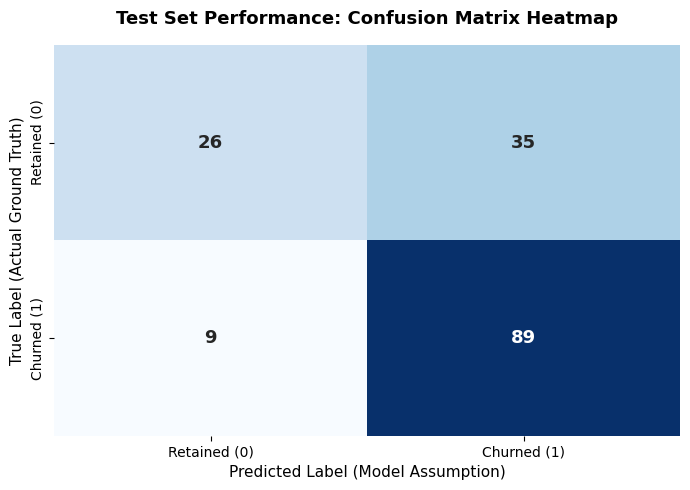

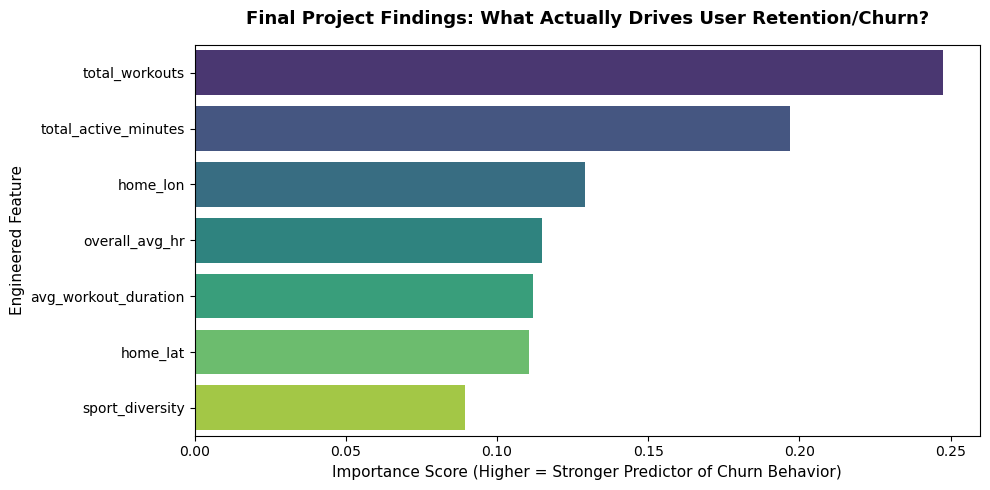

In [18]:
# TEST SET EVALUATION & FEATURE IMPORTANCE
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import pandas as pd

# Ensure the project output folder exists
os.makedirs('output', exist_ok=True)

# Set our champion model to the tuned Random Forest
champion_model = best_rf

# Run predictions on the completely untouched, locked test split
y_test_pred = champion_model.predict(X_test_scaled)
y_test_prob = champion_model.predict_proba(X_test_scaled)[:, 1]

# 1. Print the official academic classification report
print("--- FINAL TESTING CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_test_pred))

# 2. Print the final confusion matrix text
print("--- TEST SET CONFUSION MATRIX ---")
cm = confusion_matrix(y_test, y_test_pred)
print(cm)
print(f"True Negatives (Active Users caught): {cm[0][0]}")
print(f"False Positives (Wasted Alerts): {cm[0][1]}")
print(f"False Negatives (Missed Churners): {cm[1][0]}")
print(f"True Positives (Saved Churners): {cm[1][1]}")

# 3. Calculate and print final locked ROC-AUC
test_auc = roc_auc_score(y_test, y_test_prob)
print(f"\nFinal Locked Test ROC-AUC Score: {test_auc:.4f}")
print("=========================================================\n")


# EXPORT VISUALIZATION 1: CONFUSION MATRIX HEATMAP
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=['Retained (0)', 'Churned (1)'], 
    yticklabels=['Retained (0)', 'Churned (1)'],
    cbar=False,
    annot_kws={"size": 13, "weight": "bold"}
)
plt.title('Test Set Performance: Confusion Matrix Heatmap', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Predicted Label (Model Assumption)', fontsize=11)
plt.ylabel('True Label (Actual Ground Truth)', fontsize=11)
plt.tight_layout()

# Save the confusion matrix to the output folder BEFORE showing it
plt.savefig('output/confusion_matrix.png', dpi=300)
plt.show()


# EXPORT VISUALIZATION 2: FEATURE IMPORTANCES BARPLOT
importances = champion_model.feature_importances_
feature_names = X.columns

# Build a clean mapping DataFrame
importance_df = pd.DataFrame({
    'User Habit Metric': feature_names,
    'Importance Score': importances
}).sort_values(by='Importance Score', ascending=False).reset_index(drop=True)

# Generate the final presentation graphic
plt.figure(figsize=(10, 5))
sns.barplot(
    x='Importance Score', 
    y='User Habit Metric', 
    data=importance_df, 
    palette='viridis' # Beautiful professional gradient scale
)
plt.title('Final Project Findings: What Actually Drives User Retention/Churn?', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Importance Score (Higher = Stronger Predictor of Churn Behavior)', fontsize=11)
plt.ylabel('Engineered Feature', fontsize=11)
plt.tight_layout()

# Save the feature importance plot to the output folder BEFORE showing it
plt.savefig('output/feature_importance.png', dpi=300)
plt.show()